# 1. Import and Install Dependencies

In [1]:
!pip install tensorflow==2.14.1 opencv-python mediapipe scikit-learn matplotlib

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   --------- ------------------------------ 3.7/15.8 MB 19.8 MB/s eta 0:00:01
   ------------------- -------------------- 7.6/15.8 MB 19.6 MB/s eta 0:00:01
   ------------------------------ --------- 12.1/15.8 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------  15.7/15.8 MB 20.6 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 17.4 MB/s  0:00:00
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/39.5 MB 23.2 MB/s eta 0:00:02
   ---------- ----------------------------- 10.5/39.5 MB 25.2 MB/s eta 0:00:02
   --

In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Models

In [3]:
mp_pose = mp.solutions.pose
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

In [4]:
def mediapipe_detection(image, models):
    pose_model, hands_model = models
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgb_image.flags.writeable = False
    pose_results = pose_model.process(rgb_image)
    hands_results = hands_model.process(rgb_image)
    rgb_image.flags.writeable = True
    return image, (pose_results, hands_results)

In [5]:
def draw_landmarks(image, results):
    pose_results, hands_results = results
    mp_drawing.draw_landmarks(image, pose_results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    if hands_results.multi_hand_landmarks:
        for hand_landmarks in hands_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)

In [6]:
def draw_styled_landmarks(image, results):
    pose_results, hands_results = results
    mp_drawing.draw_landmarks(
        image, pose_results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
    )
    if hands_results.multi_hand_landmarks:
        for hand_landmarks in hands_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
            )

In [7]:
cap = cv2.VideoCapture(0)
pose_model = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
hands_model = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)
models = (pose_model, hands_model)

while cap.isOpened():
    ret, frame = cap.read()
    image, results = mediapipe_detection(frame, models)
    print(results)

    draw_styled_landmarks(image, results)

    cv2.imshow('OpenCV Feed', image)

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <clas

In [8]:
draw_landmarks(frame, results)

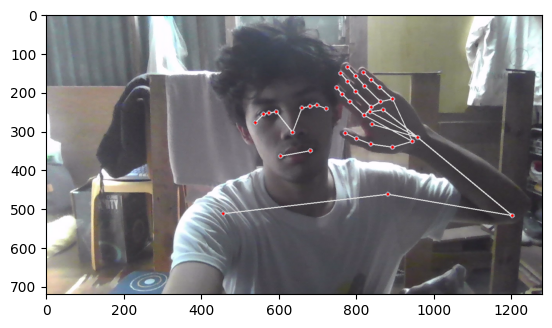

In [9]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [10]:
pose_results, hands_results = results
len(hands_results.multi_hand_landmarks[0].landmark) if hands_results.multi_hand_landmarks else 0

21

In [11]:
pose_results, hands_results = results

pose = np.array([[r.x, r.y, r.z, r.visibility] for r in pose_results.pose_landmarks.landmark]).flatten() \
    if pose_results.pose_landmarks else np.zeros(132)

lh = np.zeros(21*3)
rh = np.zeros(21*3)
if hands_results.multi_hand_landmarks:
    for landmarks, handedness in zip(hands_results.multi_hand_landmarks, hands_results.multi_handedness):
        coords = np.array([[r.x, r.y, r.z] for r in landmarks.landmark]).flatten()
        if handedness.classification[0].label == 'Left':
            lh = coords
        else:
            rh = coords

In [12]:
def extract_keypoints(results):
    pose_results, hands_results = results

    pose = np.array([[r.x, r.y, r.z, r.visibility] for r in pose_results.pose_landmarks.landmark]).flatten() \
        if pose_results.pose_landmarks else np.zeros(33*4)

    lh = np.zeros(21*3)
    rh = np.zeros(21*3)
    if hands_results.multi_hand_landmarks:
        for landmarks, handedness in zip(hands_results.multi_hand_landmarks, hands_results.multi_handedness):
            coords = np.array([[r.x, r.y, r.z] for r in landmarks.landmark]).flatten()
            if handedness.classification[0].label == 'Left':
                lh = coords
            else:
                rh = coords

    return np.concatenate([pose, lh, rh])

In [13]:
result_test = extract_keypoints(results)

In [14]:
result_test

array([ 4.96945679e-01,  4.23576862e-01, -6.79337382e-01,  9.99940157e-01,
        5.15861154e-01,  3.35815728e-01, -6.39282465e-01,  9.99825954e-01,
        5.32176316e-01,  3.29984963e-01, -6.38830602e-01,  9.99832273e-01,
        5.46246886e-01,  3.25208485e-01, -6.38601124e-01,  9.99776244e-01,
        4.64834034e-01,  3.49675953e-01, -6.51781201e-01,  9.99877632e-01,
        4.49712932e-01,  3.53798091e-01, -6.51271105e-01,  9.99893725e-01,
        4.38607782e-01,  3.58146250e-01, -6.51337564e-01,  9.99882877e-01,
        5.65164804e-01,  3.38811904e-01, -3.37627351e-01,  9.99845684e-01,
        4.22437102e-01,  3.87719125e-01, -3.81046504e-01,  9.99953628e-01,
        5.33086002e-01,  4.88147914e-01, -5.62436342e-01,  9.99913275e-01,
        4.72771794e-01,  5.07114470e-01, -5.73713422e-01,  9.99945819e-01,
        6.89742804e-01,  6.43275738e-01, -1.14885822e-01,  9.99138653e-01,
        3.57489675e-01,  7.13857353e-01, -2.38063619e-01,  9.99101162e-01,
        9.40142155e-01,  

In [15]:
np.save('0', result_test)

In [16]:
np.load('0.npy')

array([ 4.96945679e-01,  4.23576862e-01, -6.79337382e-01,  9.99940157e-01,
        5.15861154e-01,  3.35815728e-01, -6.39282465e-01,  9.99825954e-01,
        5.32176316e-01,  3.29984963e-01, -6.38830602e-01,  9.99832273e-01,
        5.46246886e-01,  3.25208485e-01, -6.38601124e-01,  9.99776244e-01,
        4.64834034e-01,  3.49675953e-01, -6.51781201e-01,  9.99877632e-01,
        4.49712932e-01,  3.53798091e-01, -6.51271105e-01,  9.99893725e-01,
        4.38607782e-01,  3.58146250e-01, -6.51337564e-01,  9.99882877e-01,
        5.65164804e-01,  3.38811904e-01, -3.37627351e-01,  9.99845684e-01,
        4.22437102e-01,  3.87719125e-01, -3.81046504e-01,  9.99953628e-01,
        5.33086002e-01,  4.88147914e-01, -5.62436342e-01,  9.99913275e-01,
        4.72771794e-01,  5.07114470e-01, -5.73713422e-01,  9.99945819e-01,
        6.89742804e-01,  6.43275738e-01, -1.14885822e-01,  9.99138653e-01,
        3.57489675e-01,  7.13857353e-01, -2.38063619e-01,  9.99101162e-01,
        9.40142155e-01,  

# 4. Setup Folders for Collection

In [17]:
import shutil
shutil.rmtree('MP_Data', ignore_errors=True)

In [18]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['kamusta', 'salamat', 'mahalkita', 'oo', 'hindi'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 0

In [19]:
for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    for sequence in range(no_sequences):
        os.makedirs(os.path.join(action_path, str(sequence)), exist_ok=True)

# 5. Collect Keypoint Values for Training and Testing

In [20]:
import time

def record_action(action, cap, models):
    for sequence in range(no_sequences):
        for frame_num in range(sequence_length):
            ret, frame = cap.read()
            image, results = mediapipe_detection(frame, models)   
            draw_styled_landmarks(image, results)

            if frame_num == 0:
                cv2.putText(image, 'STARTING COLLECTION', (120, 200),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
                cv2.waitKey(2000)
            else:
                cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)

            keypoints = extract_keypoints(results)
            sequence_dir = os.path.join(DATA_PATH, action, str(sequence))
            os.makedirs(sequence_dir, exist_ok=True)
            npy_path = os.path.join(sequence_dir, str(frame_num))
            np.save(npy_path, keypoints)

            key = cv2.waitKey(10) & 0xFF

            if key == ord('e'):
                while True:
                    ret, pause_frame = cap.read()
                    cv2.putText(pause_frame, 'PAUSED - press E to resume', (60, 240),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 3, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', pause_frame)
                    resume_key = cv2.waitKey(10) & 0xFF
                    if resume_key == ord('e'):
                        break
                    if resume_key == ord('q'):
                        return "stopped"

                for countdown in range(5, 0, -1):
                    ret, cd_frame = cap.read()
                    cv2.putText(cd_frame, f'Resuming in {countdown}...', (100, 240),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', cd_frame)
                    cv2.waitKey(1000)

            if key == ord('q'):
                return "stopped"

    return "done"

In [21]:
cap = cv2.VideoCapture(0)
pose_model = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
hands_model = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)
models = (pose_model, hands_model)

In [22]:
record_action('kamusta', cap, models)

'done'

In [23]:
record_action('salamat', cap, models)

'done'

In [24]:
record_action('mahalkita', cap, models)

'done'

In [25]:
record_action('oo', cap, models)

'done'

In [26]:
record_action('hindi', cap, models)

'done'

In [27]:
pose_model.close()
hands_model.close()
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [28]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [29]:
label_map = {label:num for num, label in enumerate(actions)}

In [30]:
label_map

{'kamusta': 0, 'salamat': 1, 'mahalkita': 2, 'oo': 3, 'hindi': 4}

In [31]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [32]:
np.array(sequences).shape

(150, 30, 258)

In [33]:
np.array(labels).shape

(150,)

In [34]:
X = np.array(sequences)

In [35]:
X.shape

(150, 30, 258)

In [36]:
y = to_categorical(labels).astype(int)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
y_test.shape

(30, 5)

# 7. Build and Train LSTM Neural Network

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

In [40]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
early_stop = EarlyStopping(monitor='val_categorical_accuracy', patience=100, restore_best_weights=True)

In [41]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,258)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [42]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [43]:
model.fit(X_train, y_train, epochs=2000, validation_data=(X_test, y_test), callbacks=[tb_callback, early_stop])

Epoch 1/2000
4/4 [==============================] - 12s 642ms/step - loss: 1.6252 - categorical_accuracy: 0.2000 - val_loss: 1.5943 - val_categorical_accuracy: 0.2000
Epoch 2/2000
4/4 [==============================] - 0s 82ms/step - loss: 1.5797 - categorical_accuracy: 0.2833 - val_loss: 1.5320 - val_categorical_accuracy: 0.4333
Epoch 3/2000
4/4 [==============================] - 0s 85ms/step - loss: 1.5496 - categorical_accuracy: 0.4000 - val_loss: 1.4088 - val_categorical_accuracy: 0.2667
Epoch 4/2000
4/4 [==============================] - 0s 82ms/step - loss: 1.2692 - categorical_accuracy: 0.4000 - val_loss: 1.3417 - val_categorical_accuracy: 0.3333
Epoch 5/2000
4/4 [==============================] - 0s 80ms/step - loss: 1.2130 - categorical_accuracy: 0.4250 - val_loss: 1.2110 - val_categorical_accuracy: 0.2667
Epoch 6/2000
4/4 [==============================] - 0s 80ms/step - loss: 1.1567 - categorical_accuracy: 0.4333 - val_loss: 1.0926 - val_categorical_accuracy: 0.4667
Epoch 7/

In [44]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            82688     
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 5)                 165       
                                                                 
Total params: 237317 (927.02 KB)
Trainable params: 23731

# 8. Make Predictions

In [45]:
res = model.predict(X_test)

1/1 [==============================] - 1s 848ms/step


In [47]:
actions[np.argmax(res[0])]

'salamat'

In [48]:
actions[np.argmax(y_test[0])]

'salamat'

# 9. Save Weights

In [49]:
model.save('action.h5')
model.save('action.keras')

C:\Users\user\anaconda3\envs\tensorflow_2\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [50]:
import json
with open('labels.json', 'w') as f:
    json.dump(actions.tolist(), f)
    config = {
    "sequence_length": sequence_length,
    "num_features": 258,
    "threshold": 0.7
}
with open('config.json', 'w') as f:
    json.dump(config, f)

In [ ]:
del model

In [51]:
model.load_weights('action.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [52]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [53]:
yhat = model.predict(X_train)

4/4 [==============================] - 0s 21ms/step


In [54]:
ytrue = np.argmax(y_train, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [55]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[96,  0],
        [ 0, 24]],

       [[96,  0],
        [ 0, 24]],

       [[86, 10],
        [ 5, 19]],

       [[90,  6],
        [13, 11]],

       [[93,  3],
        [ 1, 23]]], dtype=int64)

In [56]:
accuracy_score(ytrue, yhat)

0.8416666666666667

# 11. Test in Real Time

In [57]:
from scipy import stats

In [58]:
colors = [(245,117,16), (117,245,16), (16,117,245)]

res = res.flatten()

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    # Clip loop to the shortest length to avoid index errors
    for num, prob in enumerate(res[:len(actions)]):
        cv2.rectangle(
            output_frame,
            (0, 60 + num*40),
            (int(prob * 100), 90 + num*40),
            colors[num % len(colors)],  # cycle colors if fewer than actions
            -1
        )
        cv2.putText(
            output_frame,
            actions[num],
            (0, 85 + num*40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
            cv2.LINE_AA
        )
    return output_frame

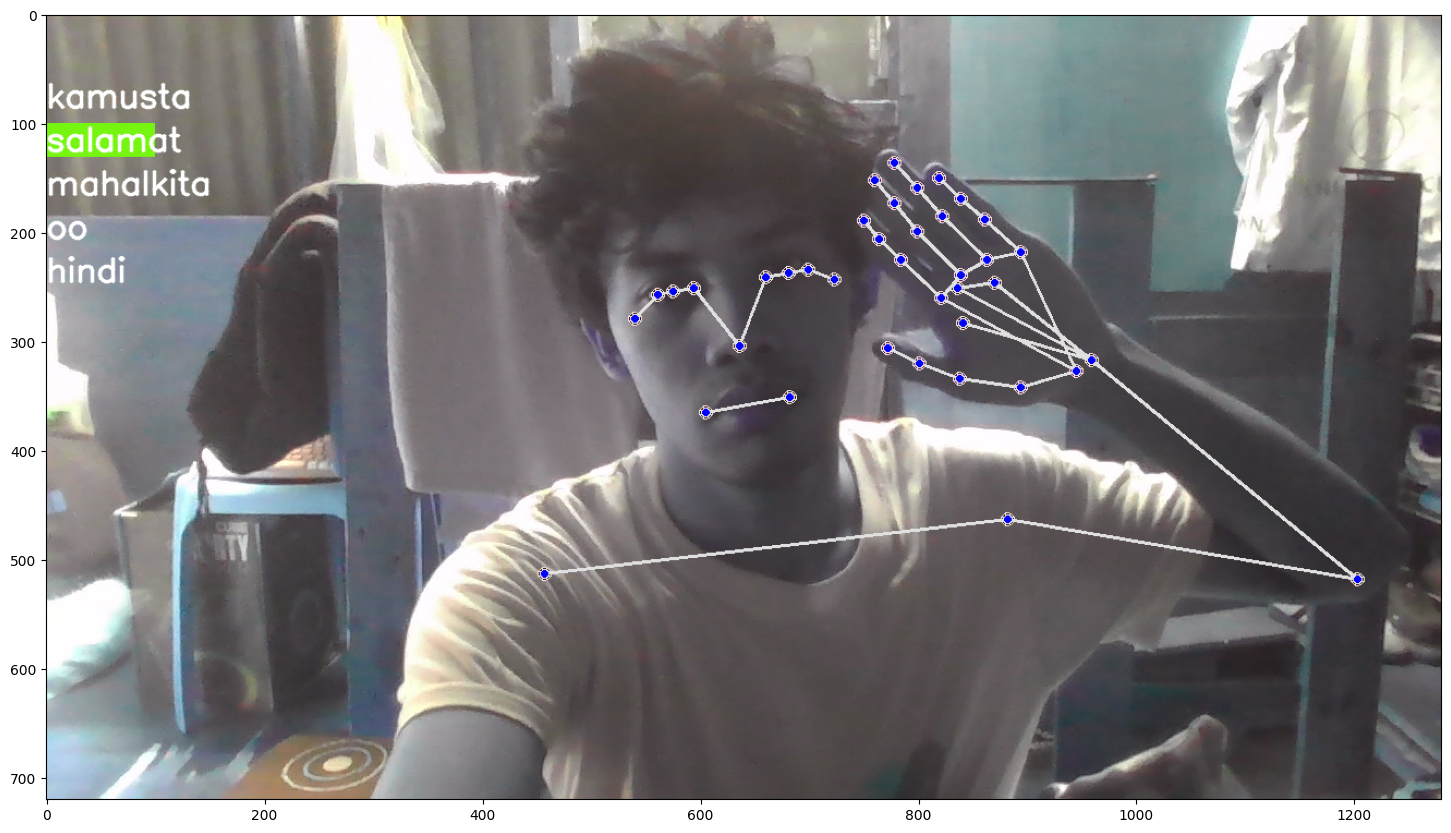

In [59]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [ ]:
sequence = []
sentence = []
predictions = []
threshold = 0.7

cap = cv2.VideoCapture(0)

# Set MediaPipe model
pose_model = mp_pose.Pose(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

hands_model = mp_hands.Hands(
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

models = (pose_model, hands_model)

while cap.isOpened():
    ret, frame = cap.read()

    image, results = mediapipe_detection(frame, models)
    print(results)

    # Draw landmarks
    draw_styled_landmarks(image, results)

    # 2. Prediction logic
    keypoints = extract_keypoints(results)
    sequence.append(keypoints)
    sequence = sequence[-30:]

    if len(sequence) == 30:
        res = model.predict(
            np.expand_dims(sequence, axis=0)
        )[0]

        print(actions[np.argmax(res)])
        predictions.append(np.argmax(res))

        # 3. Viz logic
        if np.unique(predictions[-10:])[0] == np.argmax(res):
            if res[np.argmax(res)] > threshold:

                if len(sentence) > 0:
                    if actions[np.argmax(res)] != sentence[-1]:
                        sentence.append(actions[np.argmax(res)])
                else:
                    sentence.append(actions[np.argmax(res)])

        if len(sentence) > 5:
            sentence = sentence[-5:]

        # Viz probabilities
        image = prob_viz(
            res,
            actions,
            image,
            colors
        )

    cv2.rectangle(
        image,
        (0, 0),
        (640, 40),
        (245, 117, 16),
        -1
    )

    cv2.putText(
        image,
        ' '.join(sentence),
        (3, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    # Show to screen
    cv2.imshow('OpenCV Feed', image)

    # Break gracefully
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <clas

In [63]:
import tensorflow as tf

test_model = tf.keras.models.load_model('action.h5')
test_model.summary()

dummy_input = np.random.rand(1, 30, 258).astype('float32')
prediction = test_model.predict(dummy_input)
print(prediction)
print(actions[np.argmax(prediction)])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            82688     
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 5)                 165       
                                                                 
Total params: 237317 (927.02 KB)
Trainable params: 23731